# Resort Churn Prediction — Classical ML + Optuna + Blending

**Goal.** Predict the binary `Churned` flag for resort guests in `resort_test.csv` and write a `submission.csv` file containing `GuestID,Churned` rows.

**Workflow.**
1. Load the raw train / test CSVs straight from GitHub.
2. Clean the data: fix the corrupted-decimal amenity values, parse `BookingDate`, split the composite `Room` code, add `Region × PackageType` interactions, per-amenity spend shares, and `RoomNumber` floor / position features.
3. Export the cleaned + engineered training frame to `cleaned_data.csv`.
4. Build a `ColumnTransformer` (one-hot) for the linear / non-CatBoost models, plus a `CatBoostNativeClassifier` wrapper that passes raw categorical columns to CatBoost via `cat_features`.
5. Bake-off 7 model families with 5-fold stratified CV and ROC-AUC. Compare CatBoost one-hot vs native handling.
6. Tune **CatBoost (native)** and **LogisticRegression** with Optuna (TPE, 5-fold CV).
7. Stack them — measure OOF blend AUC vs each model alone — and re-fit both on the full training set.
8. Average the two predicted-probability vectors on the test set, threshold at 0.5, and write `submission.csv`.

Each section is self-contained and re-runnable from the top.

## 1. Imports

Standard PyData stack plus the three boosted-tree libraries (`xgboost`, `lightgbm`, `catboost`) and `optuna` for hyper-parameter search.

In [1]:
# If anything is missing, uncomment:
# %pip install pandas numpy scikit-learn xgboost lightgbm catboost optuna matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the data

We load directly from the GitHub `raw.githubusercontent.com` host — the `github.com/.../blob/...` URL would return rendered HTML rather than the CSV bytes.

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
TEST_URL  = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv"

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

print(f"Train shape: {train_raw.shape}")
print(f"Test  shape: {test_raw.shape}")
train_raw.head()

Train shape: (6954, 21)
Test  shape: (1739, 20)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


### 2a. Quick look at the schema and class balance

In [3]:
summary = pd.DataFrame({
    "dtype": train_raw.dtypes,
    "missing": train_raw.isna().sum(),
    "missing_pct": (train_raw.isna().mean() * 100).round(1),
    "nunique": train_raw.nunique(),
})
print("Target balance:")
print(train_raw["Churned"].value_counts(normalize=True).round(3).rename("share").to_frame())
print()
summary

Target balance:
         share
Churned       
1        0.504
0        0.496



,dtype,missing,missing_pct,nunique
GuestID,int64,0,0.0,6954
BookingDate,object,0,0.0,658
PromoCode,object,3245,46.7,2
Region,object,169,2.4,3
AllInclusive,float64,168,2.4,2
Room,object,386,5.6,5297
PackageType,object,153,2.2,3
Age,float64,476,6.8,80
VIP,float64,158,2.3,2
RoomService,float64,464,6.7,1197


## 3. Cleaning + feature engineering

### 3a. Amenity outlier rule (decimal-corruption fix)

The amenity-spend columns — `RoomService`, `Dining`, `Retail`, `Spa`, `Entertainment` — are *supposed* to be integers. The dataset contains a handful of absurd six-figure values like `336519.8436426201`, and every one of them has a non-zero fractional part. We treat that as a data-entry corruption rather than a real spend value.

**Per-row rule** (applies independently to each guest):

1. A cell is **bad** if it is missing *or* has a non-zero fractional part.
2. If at least one of the 5 amenity cells is **good** (clean integer), replace every bad cell in that row with the *rounded mean* of the good cells — assume the guest used the amenity but the value got mangled in recording.
3. If **all 5** cells are bad, we have no information to lean on, so fill them all with **0** (assume no amenity usage).

### 3b. Other engineering

* **`BookingDate`** → year, month, day-of-week, is-weekend, days-since-earliest-booking.
* **`Room`** (e.g. `"G/630/S"`) → split into `RoomBuilding`, `RoomNumber`, `RoomSection`.
* **`RoomNumber`** (NEW) → `RoomFloor` (`// 100`, treating ~100 rooms-per-floor as a heuristic), `RoomOnFloor` (`% 100`), and `RoomPositionInBuilding` (`RoomNumber / building_max_room`, building max computed from train only).
* **`Age`** — `0.0` is a sentinel for unknown, so replace with NaN and add an `AgeKnown` flag.
* **Spend aggregates** — `TotalSpend`, `TotalSpend_log`, `SpendCategories`, per-column `log1p`.
* **Spend shares** (NEW) — `RoomService_share`, `Dining_share`, etc., each `column / TotalSpend` (0 when `TotalSpend == 0`).
* **Interaction** (NEW) — `Region_PackageType` = concatenation of the two strings, so trees can learn region-specific package effects without manually enumerating combinations.
* **Missing-indicator columns** for the fields where NaN itself is a signal (`PromoCode`, `AllInclusive`, `Region`).
* **Drop** `BookingDate` and the original `Room` string.

In [4]:
AMENITIES = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]
EARLIEST_BOOKING = pd.to_datetime(train_raw["BookingDate"], errors="coerce").min()

# Per-building max room number, computed from TRAIN only (no test-set leakage).
# Used by RoomPositionInBuilding to express RoomNumber as a 0-1 fraction.
_rp = train_raw["Room"].fillna("").str.split("/", expand=True)
BUILDING_MAX_ROOM = (
    pd.DataFrame({"b": _rp[0].replace("", np.nan),
                  "n": pd.to_numeric(_rp[1], errors="coerce")})
    .dropna()
    .groupby("b")["n"].max()
    .astype(int)
    .to_dict()
)
print(f"Earliest booking in train: {EARLIEST_BOOKING.date()}")
print(f"Max room number per building (from train): {BUILDING_MAX_ROOM}")

Earliest booking in train: 2023-01-01
Max room number per building (from train): {'A': 107, 'B': 353, 'C': 342, 'D': 291, 'E': 608, 'F': 1893, 'G': 1507, 'T': 3}


In [5]:
def fix_amenity_decimals(df: pd.DataFrame, cols=AMENITIES) -> pd.DataFrame:
    """Row-wise repair of corrupted decimal values in amenity-spend columns.

    A cell is "bad" if it is NaN OR has a non-zero fractional part.
    If 1-4 cells are bad, fill each with round(mean(good cells)).
    If all 5 cells are bad, fill with 0.
    """
    out = df.copy()
    vals = out[cols].astype(float)
    is_bad = vals.isna() | ((vals % 1) != 0)
    good_only = vals.mask(is_bad)
    row_means = good_only.mean(axis=1)
    fill_values = row_means.round().fillna(0)
    fixed = vals.where(~is_bad, fill_values, axis=0)
    out[cols] = fixed.astype(int)
    n_bad_cells = int(is_bad.values.sum())
    n_all_bad_rows = int(is_bad.all(axis=1).sum())
    print(f"  fixed {n_bad_cells:,} corrupted amenity cells"
          f" ({n_all_bad_rows:,} rows had all 5 columns bad -> filled with 0)")
    return out


def engineer(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """Clean + feature-engineer a raw resort dataframe. Returns a new df."""
    if label:
        print(f"[{label}] engineering...")
    out = df.copy()

    # --- Amenity decimal repair (the big-outlier fix) ---
    out = fix_amenity_decimals(out)

    # --- BookingDate ---
    bd = pd.to_datetime(out["BookingDate"], errors="coerce")
    out["BookingYear"]      = bd.dt.year
    out["BookingMonth"]     = bd.dt.month
    out["BookingDayOfWeek"] = bd.dt.dayofweek
    out["BookingIsWeekend"] = bd.dt.dayofweek.isin([5, 6]).astype("Int64")
    out["DaysSinceFirstBooking"] = (bd - EARLIEST_BOOKING).dt.days

    # --- Room: split "G/630/S" -> building / number / section ---
    room_parts = out["Room"].fillna("").str.split("/", expand=True)
    out["RoomBuilding"] = room_parts[0].replace("", np.nan)
    out["RoomNumber"]   = pd.to_numeric(room_parts[1], errors="coerce")
    out["RoomSection"]  = room_parts[2].replace("", np.nan) if room_parts.shape[1] > 2 else np.nan
    # NEW: floor / on-floor / fraction-through-building.
    out["RoomFloor"]              = (out["RoomNumber"] // 100).astype("Int64")
    out["RoomOnFloor"]            = (out["RoomNumber"] %  100).astype("Int64")
    out["RoomPositionInBuilding"] = out["RoomNumber"] / out["RoomBuilding"].map(BUILDING_MAX_ROOM)

    # --- Age: 0.0 is a sentinel for "unknown" ---
    age = out["Age"].replace(0.0, np.nan)
    out["Age"]      = age
    out["AgeKnown"] = age.notna().astype(int)

    # --- Spend aggregates / log features ---
    for col in AMENITIES:
        out[f"{col}_log"] = np.log1p(out[col])
    out["TotalSpend"]      = out[AMENITIES].sum(axis=1)
    out["TotalSpend_log"]  = np.log1p(out["TotalSpend"])
    out["SpendCategories"] = (out[AMENITIES] > 0).sum(axis=1)
    # NEW: per-amenity share of total spend (0 when TotalSpend == 0)
    denom = out["TotalSpend"].replace(0, np.nan)
    for col in AMENITIES:
        out[f"{col}_share"] = (out[col] / denom).fillna(0.0)

    # --- NEW: Region x PackageType interaction ---
    out["Region_PackageType"] = (
        out["Region"].fillna("UNK").astype(str) + "__" +
        out["PackageType"].fillna("UNK").astype(str)
    )

    # --- Missing-indicator flags where NaN is meaningful ---
    out["PromoCode_missing"]    = out["PromoCode"].isna().astype(int)
    out["Region_missing"]       = out["Region"].isna().astype(int)
    out["AllInclusive_missing"] = out["AllInclusive"].isna().astype(int)

    # --- Drop columns we no longer need ---
    out = out.drop(columns=["BookingDate", "Room"])
    return out


train_fe = engineer(train_raw, label="train")
test_fe  = engineer(test_raw,  label="test")

print("After feature engineering:")
print("  train:", train_fe.shape)
print("  test :", test_fe.shape)
train_fe.head()

[train] engineering...
  fixed 2,078 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
[test] engineering...
  fixed 523 corrupted amenity cells (0 rows had all 5 columns bad -> filled with 0)
After feature engineering:
  train: (6954, 48)
  test : (1739, 47)


,GuestID,PromoCode,Region,AllInclusive,PackageType,Age,VIP,RoomService,Dining,Retail,...,SpendCategories,RoomService_share,Dining_share,Retail_share,Spa_share,Entertainment_share,Region_PackageType,PromoCode_missing,Region_missing,AllInclusive_missing
0,619623,NaN,Americas,0.0,Relaxation,NaN,0.0,0,0,0,...,0,0.0,0.0,0.000000,0.000000,0.000000,Americas__Relaxation,1,0,0
1,776250,NaN,Americas,1.0,Relaxation,17.0,0.0,0,0,0,...,0,0.0,0.0,0.000000,0.000000,0.000000,Americas__Relaxation,1,0,0
2,932709,NaN,Americas,NaN,Wellness,35.0,0.0,0,0,0,...,0,0.0,0.0,0.000000,0.000000,0.000000,Americas__Wellness,1,0,1
3,771839,PromoA,Europe,1.0,Adventure,26.0,0.0,0,0,0,...,0,0.0,0.0,0.000000,0.000000,0.000000,Europe__Adventure,0,0,0
4,755501,PromoA,Americas,0.0,Relaxation,13.0,0.0,0,0,60,...,3,0.0,0.0,0.011521,0.000192,0.988287,Americas__Relaxation,0,0,0


In [6]:
# Sanity-check the amenity fix: post-cleaning, every amenity cell should be a
# non-negative integer with no NaNs.
amen_after = train_fe[AMENITIES]
print("Amenity column stats after cleaning:")
print(amen_after.describe().round(1).T[["min", "max", "mean", "std"]])
print(f"\nAny NaN remaining in amenity cols? {amen_after.isna().any().any()}")
print(f"Any non-integer values remaining?  {((amen_after % 1) != 0).any().any()}")

Amenity column stats after cleaning:
               min      max   mean     std
RoomService    0.0  14327.0  240.0   692.8
Dining         0.0  29813.0  433.1  1541.3
Retail         0.0  12253.0  176.0   557.0
Spa            0.0  18572.0  304.7  1097.0
Entertainment  0.0  20336.0  296.6  1098.4

Any NaN remaining in amenity cols? False
Any non-integer values remaining?  False


### 3c. Export the cleaned training data

Snapshot the cleaned + feature-engineered training frame to `cleaned_data.csv` *before* it goes through scaling / one-hot encoding. This keeps the file human-readable — original column names, raw category strings, NaNs intact — so it is easy to inspect in Excel or load into a separate analysis.

In [7]:
CLEANED_PATH = "cleaned_data.csv"
train_fe.to_csv(CLEANED_PATH, index=False)
print(f"Wrote {CLEANED_PATH}: {train_fe.shape[0]:,} rows x {train_fe.shape[1]} columns")
print("Columns:")
for c in train_fe.columns:
    print(f"  - {c}")

Wrote cleaned_data.csv: 6,954 rows x 48 columns
Columns:
  - GuestID
  - PromoCode
  - Region
  - AllInclusive
  - PackageType
  - Age
  - VIP
  - RoomService
  - Dining
  - Retail
  - Spa
  - Entertainment
  - LoyaltyPoints
  - SurveyScore
  - DaysSinceEmail
  - BookingChannel
  - AgeGroup
  - ReferralSource
  - Churned
  - BookingYear
  - BookingMonth
  - BookingDayOfWeek
  - BookingIsWeekend
  - DaysSinceFirstBooking
  - RoomBuilding
  - RoomNumber
  - RoomSection
  - RoomFloor
  - RoomOnFloor
  - RoomPositionInBuilding
  - AgeKnown
  - RoomService_log
  - Dining_log
  - Retail_log
  - Spa_log
  - Entertainment_log
  - TotalSpend
  - TotalSpend_log
  - SpendCategories
  - RoomService_share
  - Dining_share
  - Retail_share
  - Spa_share
  - Entertainment_share
  - Region_PackageType
  - PromoCode_missing
  - Region_missing
  - AllInclusive_missing


## 4. Define X / y and the one-hot preprocessor

The one-hot preprocessor feeds the linear baseline and every non-CatBoost tree model. CatBoost will get the raw DataFrame via a separate wrapper (next section).

Numeric columns → median impute + standard scale.
Categorical columns → most-frequent impute + one-hot encode (`handle_unknown='ignore'` so unseen categories in the test set do not crash).

In [8]:
TARGET = "Churned"
ID_COL = "GuestID"

y = train_fe[TARGET].astype(int).values
X = train_fe.drop(columns=[TARGET, ID_COL])
X_test = test_fe.drop(columns=[ID_COL])
# Guarantee identical column order between train and test.
X_test = X_test[X.columns]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

print(f"{len(numeric_cols)} numeric columns")
print(f"{len(categorical_cols)} categorical columns -> {categorical_cols}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

37 numeric columns
9 categorical columns -> ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomBuilding', 'RoomSection', 'Region_PackageType']


## 5. CatBoost with native categorical handling

CatBoost has a built-in encoding scheme for categorical features (ordered target statistics) that usually beats one-hot, especially on high-cardinality columns. The wrapper below makes that available through the standard sklearn interface so we can drop it into `cross_val_score` / `cross_val_predict` like any other estimator.

Design choices:

* Any `object`-dtype column in `X` is treated as categorical and passed via `cat_features=...`.
* Categorical NaNs become the literal string `"MISSING"` (CatBoost requires hashable values for cat features).
* Numeric NaNs are left in place — CatBoost handles them natively.

In [9]:
class CatBoostNativeClassifier(ClassifierMixin, BaseEstimator):
    """Sklearn-friendly CatBoost wrapper that uses native categorical handling.

    On fit, any object-dtype column in `X` is registered as a CatBoost
    `cat_features`. NaNs in those columns are converted to the string
    "MISSING" before being handed to CatBoost. Numeric NaNs are left as-is.
    """

    def __init__(self, iterations=400, depth=6, learning_rate=0.05,
                 l2_leaf_reg=3.0, bagging_temperature=1.0,
                 random_strength=1.0, border_count=128,
                 random_seed=RANDOM_STATE):
        self.iterations          = iterations
        self.depth               = depth
        self.learning_rate       = learning_rate
        self.l2_leaf_reg         = l2_leaf_reg
        self.bagging_temperature = bagging_temperature
        self.random_strength     = random_strength
        self.border_count        = border_count
        self.random_seed         = random_seed

    def _prep(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X = X.copy()
        for c in self.cat_cols_:
            X[c] = X[c].astype(object).where(X[c].notna(), "MISSING").astype(str)
        return X

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.cat_cols_ = X.select_dtypes(include=["object"]).columns.tolist()
        X_prep = self._prep(X)
        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            bagging_temperature=self.bagging_temperature,
            random_strength=self.random_strength,
            border_count=self.border_count,
            random_seed=self.random_seed,
            cat_features=self.cat_cols_,
            eval_metric="AUC",
            verbose=0,
            allow_writing_files=False,
        )
        self.model_.fit(X_prep, y)
        self.classes_ = self.model_.classes_
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(self._prep(X))

    def predict(self, X):
        return self.model_.predict(self._prep(X))

## 6. Model bake-off (baseline CV)

Score seven candidate model families with 5-fold stratified CV and ROC-AUC, all sharing the one-hot preprocessor so the comparison is apples-to-apples.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "LogReg":     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "RandForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    "GradBoost":  GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGB":     HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=None,
        random_state=RANDOM_STATE,
    ),
    "XGBoost":    xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist",
    ),
    "LightGBM":   lgb.LGBMClassifier(
        n_estimators=400, max_depth=-1, learning_rate=0.05,
        num_leaves=63, subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    "CatBoost":   CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05,
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    ),
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:11s}  AUC = {scores.mean():.4f}  +/- {scores.std():.4f}")

leaderboard = (
    pd.DataFrame({k: {"mean_auc": v.mean(), "std_auc": v.std()} for k, v in results.items()})
    .T.sort_values("mean_auc", ascending=False)
)
leaderboard

LogReg       AUC = 0.9156  +/- 0.0052
RandForest   AUC = 0.9117  +/- 0.0052
GradBoost    AUC = 0.9235  +/- 0.0041
HistGB       AUC = 0.9238  +/- 0.0038
XGBoost      AUC = 0.9258  +/- 0.0032
LightGBM     AUC = 0.9222  +/- 0.0026
CatBoost     AUC = 0.9299  +/- 0.0027


,mean_auc,std_auc
CatBoost,0.929870,0.002725
XGBoost,0.925766,0.003193
HistGB,0.923787,0.003826
GradBoost,0.923456,0.004128
LightGBM,0.922232,0.002614
LogReg,0.915647,0.005242
RandForest,0.911746,0.005232


### 6a. CatBoost one-hot vs native categorical handling

Compare matched-hyperparameter CatBoost in the two input regimes. The lift (or lack of it) decides whether the rest of the notebook is worth the extra wrapper plumbing.

In [11]:
cb_kwargs = dict(iterations=400, depth=6, learning_rate=0.05,
                 random_seed=RANDOM_STATE)

cat_onehot_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostClassifier(**cb_kwargs, verbose=0, allow_writing_files=False)),
])
cat_native = CatBoostNativeClassifier(**cb_kwargs)

onehot_scores = cross_val_score(cat_onehot_pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
native_scores = cross_val_score(cat_native,      X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"CatBoost (one-hot): {onehot_scores.mean():.4f}  +/- {onehot_scores.std():.4f}")
print(f"CatBoost (native):  {native_scores.mean():.4f}  +/- {native_scores.std():.4f}")
print(f"Native lift       : {native_scores.mean() - onehot_scores.mean():+.4f}")

CatBoost (one-hot): 0.9299  +/- 0.0027
CatBoost (native):  0.9302  +/- 0.0042
Native lift       : +0.0003


## 7. Hyper-parameter tuning with Optuna

Tune the two models we are going to stack:
* **CatBoost (native categoricals)** — the headline gradient-boosted tree model.
* **Logistic Regression** — a deliberately *different* learner. Tree ensembles and linear models tend to err on different rows, so averaging their probabilities usually gives a small but reliable AUC lift.

Both objectives use 5-fold stratified CV with ROC-AUC. CatBoost gets 30 trials (slower per trial); LogReg gets 25 (faster, smaller search space).

### 7a. CatBoost

In [12]:
N_TRIALS_CAT = 30

def objective_cat(trial: optuna.Trial) -> float:
    params = {
        "iterations":          trial.suggest_int("iterations", 300, 1500),
        "depth":               trial.suggest_int("depth", 4, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    model = CatBoostNativeClassifier(**params, random_seed=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_cat = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="resort_churn_catboost_native",
)
study_cat.optimize(objective_cat, n_trials=N_TRIALS_CAT, show_progress_bar=True)

print(f"\nBest CatBoost CV AUC : {study_cat.best_value:.4f}")
print("Best params :")
for k, v in study_cat.best_params.items():
    print(f"  {k:22s} {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best CatBoost CV AUC : 0.9307
Best params :
  iterations             1011
  depth                  4
  learning_rate          0.03198617182203562
  l2_leaf_reg            0.004809461967501573
  bagging_temperature    0.06505159298527952
  random_strength        6.24513957474307
  border_count           248


### 7b. Logistic Regression

In [13]:
N_TRIALS_LR = 25

def objective_lr(trial: optuna.Trial) -> float:
    C            = trial.suggest_float("C", 1e-3, 1e3, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    model = LogisticRegression(
        C=C, class_weight=class_weight,
        solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE,
    )
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    return cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="resort_churn_logreg",
)
study_lr.optimize(objective_lr, n_trials=N_TRIALS_LR, show_progress_bar=True)

print(f"\nBest LogReg CV AUC : {study_lr.best_value:.4f}")
print("Best params :")
for k, v in study_lr.best_params.items():
    print(f"  {k:14s} {v}")

  0%|          | 0/25 [00:00<?, ?it/s]


Best LogReg CV AUC : 0.9157
Best params :
  C              0.6111046937759403
  class_weight   None


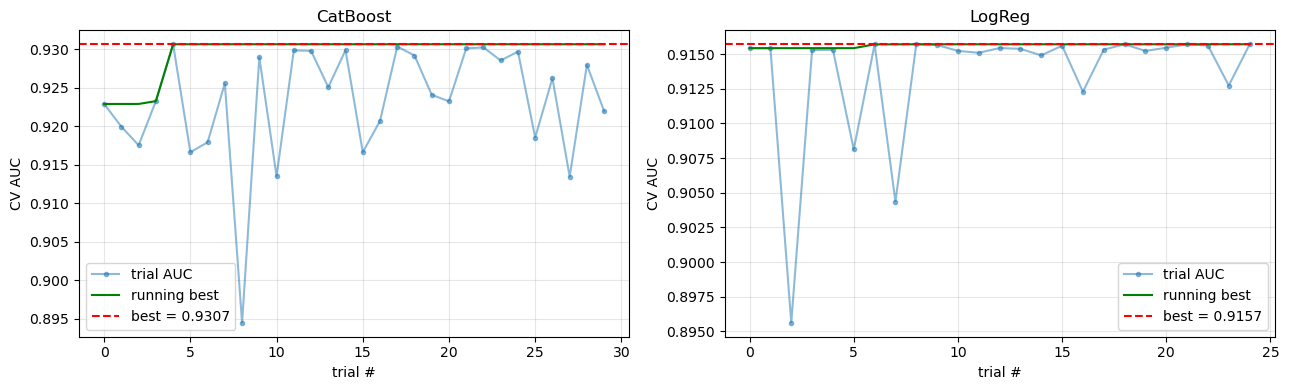

In [14]:
# Side-by-side trial history for the two studies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, study, title in zip(axes, [study_cat, study_lr], ["CatBoost", "LogReg"]):
    vals = [t.value for t in study.trials if t.value is not None]
    running = np.maximum.accumulate(vals)
    ax.plot(vals,    marker=".", alpha=0.5, label="trial AUC")
    ax.plot(running, color="green", label="running best")
    ax.axhline(study.best_value, color="red", ls="--",
               label=f"best = {study.best_value:.4f}")
    ax.set(title=title, xlabel="trial #", ylabel="CV AUC")
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

## 8. Stacking — out-of-fold blend check

Before committing to a blend, verify it actually beats either model alone on out-of-fold predictions. We use the same 5-fold split, ask each tuned model for its OOF probability of churn, then average them.

If the blend's OOF AUC is materially higher than each individual model, stacking is the right call for the submission. If not, fall back to whichever model wins.

In [15]:
best_cat_estimator = CatBoostNativeClassifier(**study_cat.best_params, random_seed=RANDOM_STATE)
best_lr_estimator  = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(**study_lr.best_params,
                                  solver="lbfgs", max_iter=2000,
                                  random_state=RANDOM_STATE)),
])

cat_oof = cross_val_predict(best_cat_estimator, X, y, cv=cv,
                            method="predict_proba", n_jobs=-1)[:, 1]
lr_oof  = cross_val_predict(best_lr_estimator,  X, y, cv=cv,
                            method="predict_proba", n_jobs=-1)[:, 1]
blend_oof = (cat_oof + lr_oof) / 2

auc_cat   = roc_auc_score(y, cat_oof)
auc_lr    = roc_auc_score(y, lr_oof)
auc_blend = roc_auc_score(y, blend_oof)

print(f"OOF AUC | CatBoost (native, tuned) : {auc_cat:.4f}")
print(f"OOF AUC | LogReg   (tuned)         : {auc_lr:.4f}")
print(f"OOF AUC | Blend (mean of probas)   : {auc_blend:.4f}")
print(f"\nBlend lift over CatBoost: {auc_blend - auc_cat:+.4f}")
print(f"Blend lift over LogReg  : {auc_blend - auc_lr:+.4f}")

USE_BLEND = auc_blend >= max(auc_cat, auc_lr)
BEST_SINGLE = "catboost" if auc_cat >= auc_lr else "logreg"
STRATEGY = "blend" if USE_BLEND else BEST_SINGLE
print(f"\nSubmission strategy: {STRATEGY}")

OOF AUC | CatBoost (native, tuned) : 0.9307
OOF AUC | LogReg   (tuned)         : 0.9157
OOF AUC | Blend (mean of probas)   : 0.9274

Blend lift over CatBoost: -0.0033
Blend lift over LogReg  : +0.0117

Submission strategy: catboost


## 9. Train the final models on all of training data

Re-fit both tuned models on the entire training set. The CV AUCs above are the honest performance estimate; the training metrics printed here are just a sanity check that nothing broke.

In [16]:
best_cat_final = CatBoostNativeClassifier(**study_cat.best_params, random_seed=RANDOM_STATE)
best_lr_final  = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(**study_lr.best_params,
                                  solver="lbfgs", max_iter=2000,
                                  random_state=RANDOM_STATE)),
])
best_cat_final.fit(X, y)
best_lr_final.fit(X, y)

train_cat_proba = best_cat_final.predict_proba(X)[:, 1]
train_lr_proba  = best_lr_final.predict_proba(X)[:, 1]
train_blend_proba = (train_cat_proba + train_lr_proba) / 2

if STRATEGY == "blend":
    train_proba = train_blend_proba
elif STRATEGY == "catboost":
    train_proba = train_cat_proba
else:
    train_proba = train_lr_proba

train_preds = (train_proba >= 0.5).astype(int)
print(f"[{STRATEGY}] Training AUC      : {roc_auc_score(y, train_proba):.4f}")
print(f"[{STRATEGY}] Training accuracy : {accuracy_score(y, train_preds):.4f}")
print(f"[{STRATEGY}] Training F1       : {f1_score(y, train_preds):.4f}")
print("\nConfusion matrix (train):")
print(confusion_matrix(y, train_preds))
print("\nClassification report (train):")
print(classification_report(y, train_preds, digits=4))

[catboost] Training AUC      : 0.9615
[catboost] Training accuracy : 0.8960
[catboost] Training F1       : 0.8962

Confusion matrix (train):
[[3111  341]
 [ 382 3120]]

Classification report (train):
              precision    recall  f1-score   support

           0     0.8906    0.9012    0.8959      3452
           1     0.9015    0.8909    0.8962      3502

    accuracy                         0.8960      6954
   macro avg     0.8961    0.8961    0.8960      6954
weighted avg     0.8961    0.8960    0.8960      6954



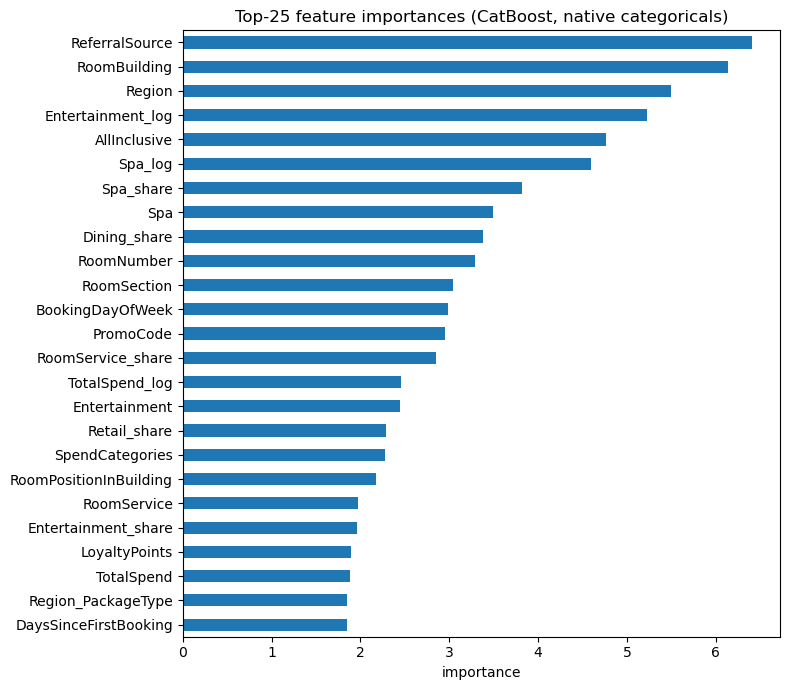

In [17]:
# Top-25 feature importances from the tuned CatBoost model
# (PredictionValuesChange — CatBoost's default for classification).
feature_names = best_cat_final.model_.feature_names_
importances   = best_cat_final.model_.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
fi[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (CatBoost, native categoricals)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 10. Predict on the test set + write `submission.csv`

Generate test probabilities from both fitted models, average them (or fall back to the best single model per the OOF strategy chosen above), threshold at 0.5, and write the two-column `GuestID,Churned` file.

In [18]:
test_cat_proba = best_cat_final.predict_proba(X_test)[:, 1]
test_lr_proba  = best_lr_final.predict_proba(X_test)[:, 1]

if STRATEGY == "blend":
    test_proba = (test_cat_proba + test_lr_proba) / 2
elif STRATEGY == "catboost":
    test_proba = test_cat_proba
else:
    test_proba = test_lr_proba

test_preds = (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "GuestID": test_fe[ID_COL].values,
    "Churned": test_preds,
})
submission.to_csv("submission.csv", index=False)

print(f"Strategy used      : {STRATEGY}")
print(f"Wrote submission.csv with {len(submission)} rows")
print(f"Predicted churn rate: {submission['Churned'].mean():.2%}")
submission.head()

Strategy used      : catboost
Wrote submission.csv with 1739 rows
Predicted churn rate: 48.30%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,1
4,635228,0


## 11. Notes for future iterations

* **Threshold tuning.** We hard-coded 0.5 because the deliverable wants {0,1}. If the grader uses F1 or business cost, sweep the threshold on the OOF blend (`blend_oof`) and pick the operating point that maximises that metric — no extra training required.
* **Weighted blend.** A simple mean assumes both models are equally trustworthy. Try `w * cat_oof + (1 - w) * lr_oof` and grid-search `w in [0, 1]` against `blend_oof` — when one model is clearly stronger, a weight ~0.7 / 0.3 often beats 0.5 / 0.5.
* **More trials.** TPE keeps improving with more samples. Doubling `N_TRIALS_CAT` usually squeezes another 1–2 AUC points out without changing the search space.
* **Add a third learner to the blend.** A tuned LightGBM or XGBoost would give a 3-model ensemble that often outperforms a 2-model one, since the third model fills in failure modes the first two share.